# Modelado de `valor_eur`

Partimos de `data/processed/fbref_tm_features.parquet`, generado en `03-ingenieria_variables.ipynb`. Todas las categoricas de baja cardinalidad (posicion, competicion) ya estan codificadas en dummies. La unica columna pendiente es `Squad` (130 equipos): en `03` se dejo **sin codificar a proposito**, porque el metodo elegido para reemplazar el one-hot -target encoding (media de `log_valor_eur` por equipo)- usa la variable objetivo, y calcularlo antes de separar train/test filtraria informacion del test hacia las features de entrenamiento.

Este notebook primero separa train/test **por `player_id`** (para que un mismo jugador no aparezca en ambos conjuntos, como senala el EDA) y luego ajusta el target encoding de `Squad` **solo con el train**.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import TargetEncoder

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_parquet("../data/processed/fbref_tm_features.parquet")
print(f"Shape: {df.shape}")
df.dtypes.value_counts()

Shape: (13022, 65)


int64      35
float64    27
str         3
Name: count, dtype: int64

## 1. Split train/test por `player_id`

Se separan los `player_id` unicos (no las filas) antes de filtrar el `df`, para que todas las temporadas de un mismo jugador queden del mismo lado del split.

In [3]:
TARGET = "log_valor_eur"

player_ids = df["player_id"].unique().to_numpy()
train_ids, test_ids = train_test_split(player_ids, test_size=0.2, random_state=42)

df_train = df[df["player_id"].isin(train_ids)].copy()
df_test = df[df["player_id"].isin(test_ids)].copy()

print(f"Train: {df_train.shape[0]} filas, {df_train['player_id'].nunique()} jugadores")
print(f"Test:  {df_test.shape[0]} filas, {df_test['player_id'].nunique()} jugadores")
print(f"Jugadores en ambos conjuntos: {len(set(train_ids) & set(test_ids))}")

Train: 10352 filas, 4331 jugadores
Test:  2670 filas, 1083 jugadores
Jugadores en ambos conjuntos: 0


## 2. Target encoding de `Squad` (ajustado solo con train)

`sklearn.preprocessing.TargetEncoder` reemplaza cada equipo por una estimacion regularizada (*shrinkage* hacia la media global, ponderada por la frecuencia del equipo) de la media de `log_valor_eur` -exactamente el mean encoding suavizado descrito en `03-ingenieria_variables.ipynb` (seccion 7.3). Ademas, `fit_transform` aplica *cross-fitting* interno (K-fold) sobre el propio train, para que la codificacion de cada fila no use el target de esa misma fila.

Clave para evitar fuga de informacion: se hace `fit_transform` **solo sobre train** y luego `transform` (no `fit`) sobre test, de forma que ninguna media de equipo usada en las features de test provenga de targets del propio test.

In [4]:
encoder = TargetEncoder(
    target_type="continuous",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
)

df_train["Squad_target_enc"] = encoder.fit_transform(
    df_train[["Squad"]], df_train[TARGET]
).ravel()
df_test["Squad_target_enc"] = encoder.transform(df_test[["Squad"]]).ravel()

df_train = df_train.drop(columns=["Squad"])
df_test = df_test.drop(columns=["Squad"])

print(f"Equipos vistos en train: {len(encoder.categories_[0])}")
df_train[["Squad_target_enc"]].describe()

Equipos vistos en train: 130


,Squad_target_enc
count,10352.000000
mean,6.644787
std,0.346126
min,5.558113
25%,6.352594
50%,6.638643
75%,6.923787
max,7.528226


## 3. Regresión lineal simple (baseline)

Antes de probar nada más sofisticado, entrenamos una regresión lineal ordinaria (sin regularización) sobre todas las features numéricas disponibles, como punto de partida para medir cuánta señal capturan y dónde falla el modelo más simple posible.

Se predice `log_valor_eur` (no `valor_eur` directamente: la distribución de `valor_eur` es muy asimétrica, como vimos en el EDA, y un modelo lineal en escala log se ajusta mucho mejor). Del conjunto de features se excluyen:
- `Player`, `player_id`, `saison_id`: identificadores, no características del jugador.
- `valor_eur`: es la variable objetivo sin transformar — incluirla sería fuga de información directa (`log_valor_eur = log10(valor_eur)`).

In [5]:
ID_COLS = ["Player", "player_id", "saison_id"]
TARGET_COLS = ["valor_eur", "log_valor_eur"]

feature_cols = [c for c in df_train.columns if c not in ID_COLS + TARGET_COLS]

X_train, y_train = df_train[feature_cols], df_train[TARGET]
X_test, y_test = df_test[feature_cols], df_test[TARGET]

print(f"Features usadas: {len(feature_cols)}")
print(f"Tipos de dato en X_train:\n{X_train.dtypes.value_counts()}")

Features usadas: 60
Tipos de dato en X_train:
int64      34
float64    26
Name: count, dtype: int64


In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
pred_test = lr.predict(X_test)

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def evaluar(y_true_log, y_pred_log, nombre):
    r2 = r2_score(y_true_log, y_pred_log)
    rmse_log = mean_squared_error(y_true_log, y_pred_log) ** 0.5
    mae_log = mean_absolute_error(y_true_log, y_pred_log)

    # log_valor_eur = log10(valor_eur) -> deshacemos el log para interpretar el error en euros
    y_true_eur = 10 ** y_true_log
    y_pred_eur = 10 ** y_pred_log
    mae_eur = mean_absolute_error(y_true_eur, y_pred_eur)
    mape_eur = (np.abs((y_true_eur - y_pred_eur) / y_true_eur)).mean() * 100

    print(f"--- {nombre} ---")
    print(f"R2 (log10):   {r2:.3f}")
    print(f"RMSE (log10): {rmse_log:.3f}")
    print(f"MAE (log10):  {mae_log:.3f}")
    print(f"MAE (EUR):    {mae_eur:,.0f}")
    print(f"MAPE (EUR):   {mape_eur:.1f}%")
    print()


evaluar(y_train, pred_train, "Train")
evaluar(y_test, pred_test, "Test")

--- Train ---
R2 (log10):   0.727
RMSE (log10): 0.327
MAE (log10):  0.245
MAE (EUR):    4,484,221
MAPE (EUR):   79.0%

--- Test ---
R2 (log10):   0.731
RMSE (log10): 0.326
MAE (log10):  0.245
MAE (EUR):    4,825,014
MAPE (EUR):   78.0%



## 4. Análisis de coeficientes

Los coeficientes crudos de `lr.coef_` **no son comparables entre sí** porque las features están en escalas muy distintas: dummies binarias (0/1), variables `_rs` (robust-scaled), conteos crudos (`Performance_PK`, 0-5) y `Squad_target_enc` (ya en escala log10 de valor). Un coeficiente grande en una variable con rango [0, 1] no implica más impacto que uno pequeño en una variable con rango [0, 100].

Para comparar de forma justa, se calcula el **impacto estandarizado**: `coef_i * std(X_i)`, que representa el cambio esperado en `log_valor_eur` ante un incremento de una desviación estándar en esa variable (manteniendo las demás constantes) — el equivalente a estandarizar las features antes de entrenar, pero reutilizando el mismo modelo ya ajustado.

In [8]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": lr.coef_,
    "std_feature": X_train.std().values,
})
coef_df["impacto_std"] = coef_df["coef"] * coef_df["std_feature"]
coef_df = coef_df.sort_values("impacto_std", key=np.abs, ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)
print("Top 15 variables con mayor impacto (positivo o negativo) sobre log_valor_eur:")
coef_df.head(15)

Top 15 variables con mayor impacto (positivo o negativo) sobre log_valor_eur:


,feature,coef,std_feature,impacto_std
0,Playing Time_Min%,0.009411,29.363511,0.276338
1,Squad_target_enc,0.681489,0.346126,0.235881
2,Playing Time_Min_rs,-0.280044,0.579602,-0.162314
3,Age_rs,-0.210877,0.763203,-0.160942
4,Playing Time_Mn/MP,0.005694,25.476086,0.145071
5,flag_sin_titularidades,-0.336689,0.332805,-0.112052
6,Subs_unSub,-0.011274,7.154917,-0.080662
7,flag_sin_tiros,-0.177355,0.384338,-0.068164
8,Team Success_onG,0.003819,17.439883,0.066602
9,log1p_Standard_SoT,0.058759,1.082077,0.063582


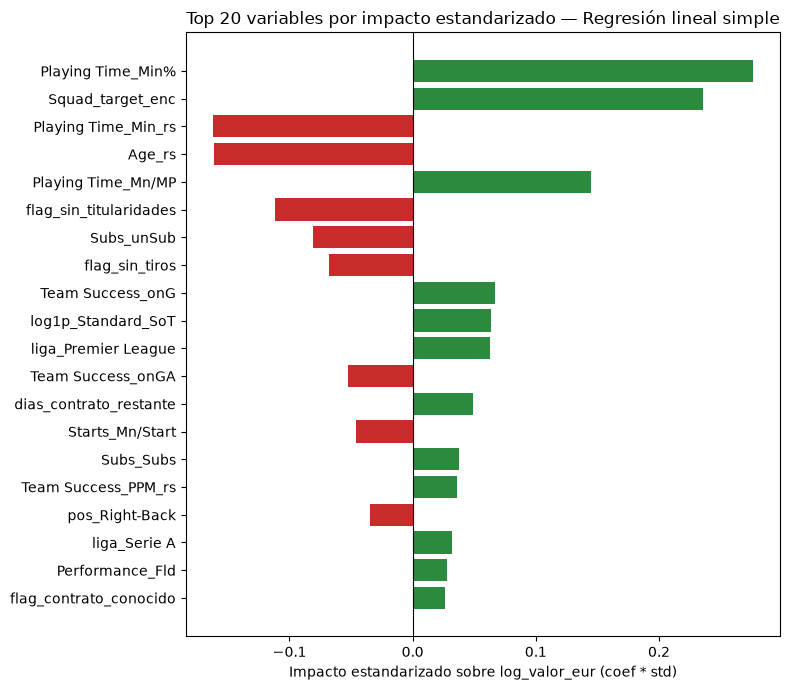

In [9]:
import matplotlib.pyplot as plt

top20 = coef_df.head(20).iloc[::-1]
colors = ["#2b8a3e" if v > 0 else "#c92a2a" for v in top20["impacto_std"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20["feature"], top20["impacto_std"], color=colors)
ax.set_xlabel("Impacto estandarizado sobre log_valor_eur (coef * std)")
ax.set_title("Top 20 variables por impacto estandarizado — Regresión lineal simple")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Análisis de residuos (test)

Se trabaja con los residuos del **test set** (no train), porque son los que reflejan el error de generalización. Se define `residuo = log_valor_eur_real - log_valor_eur_pred`: positivo significa que el modelo **subestimó** el valor del jugador; negativo, que lo **sobreestimó**.

Se revisan tres cosas:
1. Dispersión de los residuos contra el valor predicho (¿hay patrones? ¿la varianza del error crece con el valor?).
2. Distribución de los residuos (¿son aproximadamente normales, o hay asimetría/colas pesadas?).
3. Los jugadores con mayor error, para entender cualitativamente qué tipo de perfil confunde al modelo lineal.

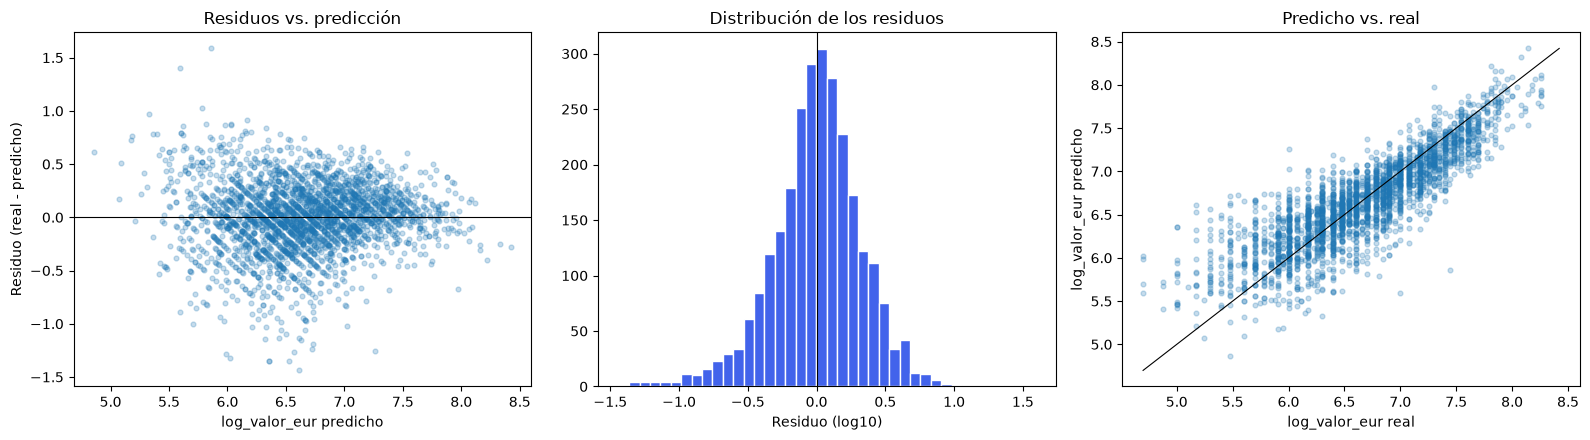

Media del residuo:    -0.0006
Desv. std del residuo: 0.3259
Asimetría (skew):      -0.4255


In [10]:
residuos_test = y_test.values - pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_test, residuos_test, alpha=0.25, s=12)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("log_valor_eur predicho")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title("Residuos vs. predicción")

axes[1].hist(residuos_test, bins=40, color="#4263eb", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Residuo (log10)")
axes[1].set_title("Distribución de los residuos")

axes[2].scatter(y_test, pred_test, alpha=0.25, s=12)
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[2].plot(lims, lims, color="black", linewidth=0.8)
axes[2].set_xlabel("log_valor_eur real")
axes[2].set_ylabel("log_valor_eur predicho")
axes[2].set_title("Predicho vs. real")

plt.tight_layout()
plt.show()

print(f"Media del residuo:    {residuos_test.mean():.4f}")
print(f"Desv. std del residuo: {residuos_test.std():.4f}")
print(f"Asimetría (skew):      {pd.Series(residuos_test).skew():.4f}")

In [11]:
resultados_test = pd.DataFrame({
    "Player": df_test["Player"].values,
    "valor_eur_real": df_test["valor_eur"].values,
    "valor_eur_pred": 10 ** pred_test,
    "residuo_log10": residuos_test,
})

print("Top 10 más SUBVALORADOS por el modelo (predijo mucho menos que el valor real):")
display(resultados_test.sort_values("residuo_log10", ascending=False).head(10))

print("\nTop 10 más SOBREVALORADOS por el modelo (predijo mucho más que el valor real):")
display(resultados_test.sort_values("residuo_log10", ascending=True).head(10))

Top 10 más SUBVALORADOS por el modelo (predijo mucho menos que el valor real):


,Player,valor_eur_real,valor_eur_pred,residuo_log10
123,Marc Cucurella,28000000.0,7.249760e+05,1.586834
604,Antonín Barák,10000000.0,3.920291e+05,1.406682
1890,Jordan Lotomba,6500000.0,6.090480e+05,1.028262
512,Sada Thioub,2000000.0,2.147393e+05,0.969118
1221,Tiago Djaló,12000000.0,1.475914e+06,0.910120
1281,Thorgan Hazard,5000000.0,6.593730e+05,0.879839
2519,Frank Onyeka,8000000.0,1.073731e+06,0.872194
767,Sergio Herrera,8000000.0,1.080919e+06,0.869297
207,Etienne Green,7000000.0,9.596101e+05,0.863003
1652,Mohamed Bamba,3000000.0,4.178976e+05,0.856051



Top 10 más SOBREVALORADOS por el modelo (predijo mucho más que el valor real):


,Player,valor_eur_real,valor_eur_pred,residuo_log10
2439,Tommaso Macchioni,150000.0,4.115121e+06,-1.438291
1418,Finley Munroe,100000.0,2.259358e+06,-1.353985
1083,Nabil Aberdin,100000.0,2.249247e+06,-1.352037
1784,Jake Evans,150000.0,3.360890e+06,-1.350363
1795,Rayan Fofana,50000.0,1.044477e+06,-1.319929
1759,Kembo Diliwidi,50000.0,9.680897e+05,-1.286946
1335,Yoel Lago,200000.0,3.691585e+06,-1.266183
1185,Bobby Clark,1000000.0,1.822679e+07,-1.260710
478,Ellis Simms,300000.0,5.233184e+06,-1.241645
665,Bobby Clark,350000.0,5.368290e+06,-1.185768


## 6. Regularización: Ridge y Lasso

El análisis de coeficientes mostró el síntoma típico de multicolinealidad: el bloque de variables de tiempo de juego (`Playing Time_Min%`, `Playing Time_Mn/MP`, `Playing Time_Min_rs`, `Starts_Mn/Start`) tenía signos contradictorios entre sí. Ridge (penalización L2) debería **estabilizar** esos coeficientes repartiendo el peso entre las variables correlacionadas sin necesariamente eliminarlas. Lasso (L1) puede ir más lejos y **llevar coeficientes exactamente a cero**, actuando como selección de variables — interesante precisamente para un bloque redundante como este, donde probablemente sobran 2-3 de las 4 variables.

A diferencia de OLS, la penalización de Ridge/Lasso **sí es sensible a la escala** de cada feature (penaliza coeficientes grandes, y una variable en escala 0-100 necesita un coeficiente más chico que una en escala 0-1 para el mismo efecto). Por eso, antes de entrenar, se estandarizan las features con `StandardScaler` ajustado **solo sobre train**.

El valor de `alpha` (fuerza de la regularización) se elige por validación cruzada dentro del train (`RidgeCV` / `LassoCV`), no a mano.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import RidgeCV

alphas_ridge = np.logspace(-2, 4, 100)
ridge = RidgeCV(alphas=alphas_ridge, cv=5)
ridge.fit(X_train_scaled, y_train)

pred_train_ridge = ridge.predict(X_train_scaled)
pred_test_ridge = ridge.predict(X_test_scaled)

print(f"Mejor alpha (Ridge, CV): {ridge.alpha_:.3f}\n")
evaluar(y_train, pred_train_ridge, "Train - Ridge")
evaluar(y_test, pred_test_ridge, "Test - Ridge")

Mejor alpha (Ridge, CV): 9.326

--- Train - Ridge ---
R2 (log10):   0.727
RMSE (log10): 0.327
MAE (log10):  0.245
MAE (EUR):    4,491,071
MAPE (EUR):   78.9%

--- Test - Ridge ---
R2 (log10):   0.731
RMSE (log10): 0.326
MAE (log10):  0.245
MAE (EUR):    4,831,470
MAPE (EUR):   77.9%



In [14]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=100, cv=5, random_state=42, max_iter=20000)
lasso.fit(X_train_scaled, y_train)

pred_train_lasso = lasso.predict(X_train_scaled)
pred_test_lasso = lasso.predict(X_test_scaled)

n_zero = (lasso.coef_ == 0).sum()
print(f"Mejor alpha (Lasso, CV): {lasso.alpha_:.5f}")
print(f"Coeficientes llevados a cero: {n_zero} de {len(lasso.coef_)}\n")
evaluar(y_train, pred_train_lasso, "Train - Lasso")
evaluar(y_test, pred_test_lasso, "Test - Lasso")

Mejor alpha (Lasso, CV): 0.00039
Coeficientes llevados a cero: 3 de 60

--- Train - Lasso ---
R2 (log10):   0.726
RMSE (log10): 0.327
MAE (log10):  0.246
MAE (EUR):    4,488,053
MAPE (EUR):   79.0%

--- Test - Lasso ---
R2 (log10):   0.731
RMSE (log10): 0.326
MAE (log10):  0.245
MAE (EUR):    4,837,111
MAPE (EUR):   77.7%



### 6.1 ¿Qué le hizo Lasso al bloque de tiempo de juego?

In [15]:
comparacion_coef = pd.DataFrame({
    "feature": feature_cols,
    # coeficiente OLS reescalado (coef * std) para que sea comparable con Ridge/Lasso,
    # que sí se entrenaron sobre features estandarizadas (ver sección 4)
    "OLS_std": lr.coef_ * X_train.std().values,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
})

playing_time_vars = ["Playing Time_Min%", "Playing Time_Mn/MP", "Playing Time_Min_rs", "Starts_Mn/Start"]
print("Bloque de tiempo de juego (los tres, en la misma escala: efecto por 1 desv. estándar):")
display(comparacion_coef[comparacion_coef["feature"].isin(playing_time_vars)])

vars_eliminadas = comparacion_coef.loc[comparacion_coef["Lasso"] == 0, "feature"].tolist()
print(f"\nVariables que Lasso llevó a cero ({len(vars_eliminadas)}):")
print(vars_eliminadas)

Bloque de tiempo de juego (los tres, en la misma escala: efecto por 1 desv. estándar):


,feature,OLS_std,Ridge,Lasso
14,Playing Time_Mn/MP,0.145071,0.141973,0.130249
15,Playing Time_Min%,0.276338,0.198338,0.109900
16,Starts_Mn/Start,-0.045773,-0.041557,-0.024158
33,Playing Time_Min_rs,-0.162314,-0.085534,-0.000000



Variables que Lasso llevó a cero (3):
['Performance_Off', 'altura_m_rs', 'Playing Time_Min_rs']


### 6.2 Comparación final: OLS vs. Ridge vs. Lasso

In [16]:
def metricas(y_true_log, y_pred_log):
    y_true_eur, y_pred_eur = 10 ** y_true_log, 10 ** y_pred_log
    return {
        "R2 (log10)": r2_score(y_true_log, y_pred_log),
        "RMSE (log10)": mean_squared_error(y_true_log, y_pred_log) ** 0.5,
        "MAE (EUR)": mean_absolute_error(y_true_eur, y_pred_eur),
        "MAPE (EUR) %": (np.abs((y_true_eur - y_pred_eur) / y_true_eur)).mean() * 100,
    }

resumen = pd.DataFrame({
    "OLS": metricas(y_test, pred_test),
    "Ridge": metricas(y_test, pred_test_ridge),
    "Lasso": metricas(y_test, pred_test_lasso),
}).T
resumen

,R2 (log10),RMSE (log10),MAE (EUR),MAPE (EUR) %
OLS,0.730721,0.325863,4.825014e+06,78.027386
Ridge,0.731026,0.325678,4.831470e+06,77.877066
Lasso,0.731312,0.325505,4.837111e+06,77.729490


### 6.3 Análisis comparado de errores: OLS vs. Ridge vs. Lasso

Los tres comparten arquitectura (lineal) pero difieren en regularización. Antes de pasar a los modelos de árbol, vale la pena entender **qué tipo de jugador confunde a la familia lineal en su conjunto**: si los tres se equivocan con los mismos jugadores (la relación real no es lineal, el problema no se arregla regularizando) o cada uno falla distinto (ahí sí importa la elección de regularización).

`posicion_tm`, `Comp` y `Age` ya no están en `df_test` como columnas legibles (`03-ingenieria_variables.ipynb` las convirtió en dummies/`_rs`) -- se recuperan uniendo por `player_id` + `saison_id` contra `fbref_tm_eda.parquet`, solo para poder segmentar el análisis de error, no para modelar.

In [17]:
df_eda_ref = pd.read_parquet("../data/processed/fbref_tm_eda.parquet")[
    ["player_id", "saison_id", "posicion_tm", "Comp", "Age"]
]
# fbref_tm_eda.parquet aun no pasa por el dedup de club_coincide de la seccion 2.1
# (eso lo resuelve 03-ingenieria_variables.ipynb) -- para este analisis de error solo
# necesitamos una etiqueta descriptiva, asi que basta con quedarnos con una fila por
# (player_id, saison_id), no hace falta repetir la logica de club_coincide.
df_eda_ref = df_eda_ref.drop_duplicates(subset=["player_id", "saison_id"], keep="first")

errores = df_test[["Player", "player_id", "saison_id", "valor_eur"]].copy()
errores = errores.merge(df_eda_ref, on=["player_id", "saison_id"], how="left")
assert len(errores) == len(df_test), "el merge no debe cambiar el numero de filas"

errores["pred_OLS"] = 10 ** pred_test
errores["pred_Ridge"] = 10 ** pred_test_ridge
errores["pred_Lasso"] = 10 ** pred_test_lasso

for modelo in ["OLS", "Ridge", "Lasso"]:
    errores[f"residuo_{modelo}"] = y_test.values - np.log10(errores[f"pred_{modelo}"])

errores[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].describe()

,residuo_OLS,residuo_Ridge,residuo_Lasso
count,2670.000000,2670.000000,2670.000000
mean,-0.000575,-0.000367,-0.000087
std,0.325923,0.325739,0.325566
min,-1.438291,-1.434080,-1.430544
25%,-0.177843,-0.178174,-0.179443
50%,0.014384,0.013278,0.015510
75%,0.197643,0.196185,0.196886
max,1.586834,1.590856,1.597113


In [18]:
corr_residuos = errores[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].corr()
print("Correlación entre los residuos (log10) de los 3 modelos:")
corr_residuos

Correlación entre los residuos (log10) de los 3 modelos:


,residuo_OLS,residuo_Ridge,residuo_Lasso
residuo_OLS,1.000000,0.999896,0.999304
residuo_Ridge,0.999896,1.000000,0.999670
residuo_Lasso,0.999304,0.999670,1.000000


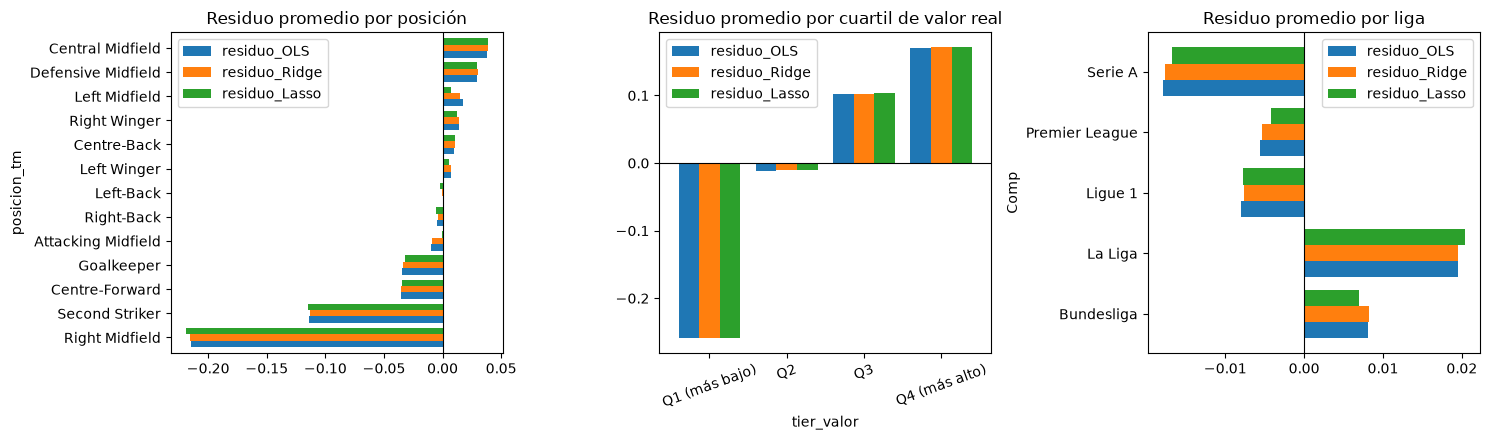

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

resumen_pos = errores.groupby("posicion_tm", observed=True)[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].mean()
resumen_pos = resumen_pos.reindex(resumen_pos["residuo_OLS"].sort_values().index)
resumen_pos.plot(kind="barh", ax=axes[0], width=0.8)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Residuo promedio por posición")

errores["tier_valor"] = pd.qcut(errores["valor_eur"], 4, labels=["Q1 (más bajo)", "Q2", "Q3", "Q4 (más alto)"])
resumen_tier = errores.groupby("tier_valor", observed=True)[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].mean()
resumen_tier.plot(kind="bar", ax=axes[1], width=0.8, rot=20)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Residuo promedio por cuartil de valor real")

resumen_liga = errores.groupby("Comp", observed=True)[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].mean()
resumen_liga.plot(kind="barh", ax=axes[2], width=0.8)
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set_title("Residuo promedio por liga")

plt.tight_layout()
plt.show()

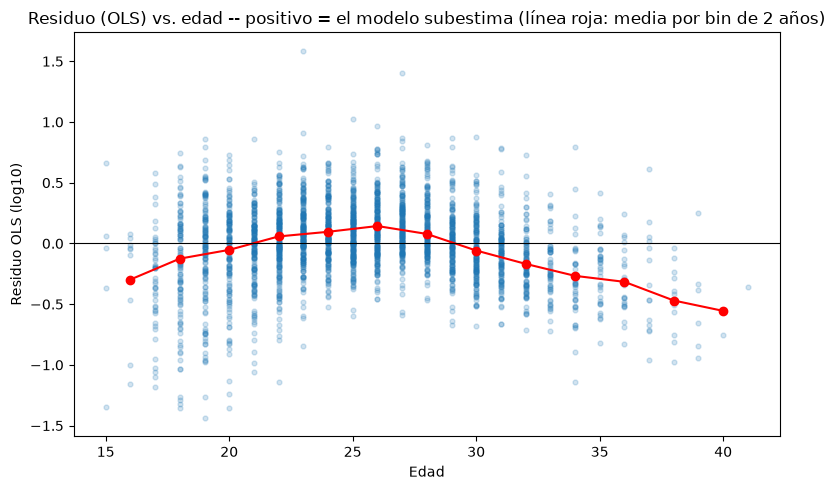

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(errores["Age"], errores["residuo_OLS"], alpha=0.2, s=12)

edad_bin_medio = errores.groupby(pd.cut(errores["Age"], bins=range(15, 42, 2)), observed=True)["residuo_OLS"].mean()
ax.plot([iv.mid for iv in edad_bin_medio.index], edad_bin_medio.values, color="red", marker="o", lw=1.5)

ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Edad")
ax.set_ylabel("Residuo OLS (log10)")
ax.set_title("Residuo (OLS) vs. edad -- positivo = el modelo subestima (línea roja: media por bin de 2 años)")
plt.tight_layout()
plt.show()

In [21]:
errores["residuo_promedio"] = errores[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].mean(axis=1)
cols_mostrar = ["Player", "posicion_tm", "Comp", "Age", "valor_eur",
                "pred_OLS", "pred_Ridge", "pred_Lasso", "residuo_promedio"]

print("Top 10 más SUBESTIMADOS -- consenso de los 3 modelos lineales:")
display(errores.sort_values("residuo_promedio", ascending=False).head(10)[cols_mostrar])

print("\nTop 10 más SOBREESTIMADOS -- consenso de los 3 modelos lineales:")
display(errores.sort_values("residuo_promedio").head(10)[cols_mostrar])

Top 10 más SUBESTIMADOS -- consenso de los 3 modelos lineales:


,Player,posicion_tm,Comp,Age,valor_eur,pred_OLS,pred_Ridge,pred_Lasso,residuo_promedio
123,Marc Cucurella,Left-Back,La Liga,23.0,28000000.0,7.249760e+05,7.182928e+05,7.080189e+05,1.591601
604,Antonín Barák,Attacking Midfield,Serie A,27.0,10000000.0,3.920291e+05,3.880192e+05,3.792007e+05,1.412986
1890,Jordan Lotomba,Right-Back,Ligue 1,25.0,6500000.0,6.090480e+05,6.127075e+05,6.197563e+05,1.024871
512,Sada Thioub,Right Winger,Ligue 1,26.0,2000000.0,2.147393e+05,2.169014e+05,2.213088e+05,0.963306
1221,Tiago Djaló,Centre-Back,Serie A,23.0,12000000.0,1.475914e+06,1.464699e+06,1.460638e+06,0.912731
2519,Frank Onyeka,Central Midfield,Premier League,27.0,8000000.0,1.073731e+06,1.065118e+06,1.050020e+06,0.876593
1281,Thorgan Hazard,Attacking Midfield,Bundesliga,30.0,5000000.0,6.593730e+05,6.721811e+05,6.858391e+05,0.871357
767,Sergio Herrera,Goalkeeper,La Liga,29.0,8000000.0,1.080919e+06,1.082721e+06,1.079383e+06,0.869262
207,Etienne Green,Goalkeeper,Ligue 1,21.0,7000000.0,9.596101e+05,9.736693e+05,9.866606e+05,0.856873
1652,Mohamed Bamba,Defensive Midfield,Ligue 1,19.0,3000000.0,4.178976e+05,4.205470e+05,4.294280e+05,0.851196



Top 10 más SOBREESTIMADOS -- consenso de los 3 modelos lineales:


,Player,posicion_tm,Comp,Age,valor_eur,pred_OLS,pred_Ridge,pred_Lasso,residuo_promedio
2439,Tommaso Macchioni,Centre-Back,Serie A,19.0,150000.0,4.115121e+06,4.075410e+06,4.042362e+06,-1.434305
1418,Finley Munroe,Left-Back,Premier League,18.0,100000.0,2.259358e+06,2.239484e+06,2.240432e+06,-1.351488
1083,Nabil Aberdin,Centre-Back,La Liga,20.0,100000.0,2.249247e+06,2.228402e+06,2.216609e+06,-1.348573
1784,Jake Evans,Centre-Forward,Premier League,15.0,150000.0,3.360890e+06,3.327364e+06,3.280122e+06,-1.345390
1795,Rayan Fofana,Centre-Forward,Ligue 1,18.0,50000.0,1.044477e+06,1.050502e+06,1.063635e+06,-1.323393
1759,Kembo Diliwidi,Left Winger,Ligue 1,18.0,50000.0,9.680897e+05,9.766676e+05,9.999000e+05,-1.292903
1335,Yoel Lago,Centre-Back,La Liga,19.0,200000.0,3.691585e+06,3.656876e+06,3.631437e+06,-1.262437
1185,Bobby Clark,Central Midfield,Premier League,18.0,1000000.0,1.822679e+07,1.810018e+07,1.786544e+07,-1.256802
478,Ellis Simms,Centre-Forward,Premier League,20.0,300000.0,5.233184e+06,5.160185e+06,5.075729e+06,-1.235189
665,Bobby Clark,Central Midfield,Premier League,17.0,350000.0,5.368290e+06,5.327941e+06,5.320772e+06,-1.183389


### 6.4 ¿Quitar `Squad_target_enc` arregla el sesgo con canteranos? -- No, se descarta

Se probó reentrenar los 5 modelos (misma configuración, mismos hiperparámetros) sin `Squad_target_enc`, para ver si el prestigio del equipo era la causa del sesgo hacia canteranos de clubes grandes (sección 6.3). Empeoró **los 5 modelos sin excepción**:

| Modelo | R² (con → sin) | MAPE (con → sin) |
|---|---|---|
| OLS | 0.731 → 0.689 | 78.0% → 84.6% |
| Ridge | 0.731 → 0.689 | 77.9% → 84.6% |
| Lasso | 0.731 → 0.690 | 77.7% → 84.1% |
| Random Forest | 0.812 → 0.774 | 57.3% → 66.1% |
| XGBoost | 0.831 → 0.803 | 53.2% → 59.5% |

`Squad_target_enc` carga señal real y sustancial (el contexto/prestigio del club sí explica parte genuina del valor de mercado). Contribuye al sesgo con canteranos, pero quitarlo de raíz sale más caro de lo que soluciona. **Se conserva la variable** y el sesgo con jugadores muy jóvenes de clubes grandes queda documentado como limitación conocida del modelo lineal (una interacción explícita `Squad_target_enc` × experiencia/minutos sería el siguiente paso natural, no explorado todavía).

## 7. Random Forest

Los tres modelos lineales convergieron al mismo techo (R² test ≈ 0.695): la multicolinealidad no era el problema real, sino la incapacidad de un modelo lineal de capturar los efectos no lineales que vimos en los residuos (piso de mercado para jugadores marginales, prima de reputación para superestrellas como Rodri). Un Random Forest, al construirse por splits, puede modelar esas no linealidades e interacciones entre variables sin que se lo digamos explícitamente, y no necesita features escaladas ni dummies "limpias" de colinealidad (cada árbol elige splits independientes).

Primero un modelo base sin ajustar hiperparámetros a mano, usando `oob_score` (out-of-bag, un tipo de validación cruzada gratis que da Random Forest) como referencia adicional junto con el train/test ya establecido.

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    oob_score=True,
)
rf.fit(X_train, y_train)

pred_train_rf = rf.predict(X_train)
pred_test_rf = rf.predict(X_test)

print(f"OOB score (R2): {rf.oob_score_:.3f}\n")
evaluar(y_train, pred_train_rf, "Train - Random Forest")
evaluar(y_test, pred_test_rf, "Test - Random Forest")

OOB score (R2): 0.814

--- Train - Random Forest ---
R2 (log10):   0.975
RMSE (log10): 0.099
MAE (log10):  0.075
MAE (EUR):    1,558,612
MAPE (EUR):   17.5%

--- Test - Random Forest ---
R2 (log10):   0.811
RMSE (log10): 0.273
MAE (log10):  0.206
MAE (EUR):    4,198,820
MAPE (EUR):   57.5%



El salto es grande (R² test 0.695 → 0.798, MAPE 86.6% → 58.5%), pero el modelo base está **sobreajustado**: R² de train = 0.973 vs. test = 0.798, una brecha mucho mayor que la de los modelos lineales (donde train y test casi no se diferenciaban). El `oob_score_` (0.797) confirma que el 0.798 de test no es casualidad del split, pero conviene limitar la profundidad/complejidad de los árboles para cerrar esa brecha y ver si mejora aún más la generalización.

Se busca `max_depth`, `min_samples_leaf` y `max_features` por validación cruzada (5-fold) sobre el train, sin tocar el test.

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 12, 16, 20, None],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", 0.5, 0.7, 1.0],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", rf_search.best_params_)
print(f"R2 CV (train): {rf_search.best_score_:.3f}\n")

rf_tuned = rf_search.best_estimator_
pred_train_rf_tuned = rf_tuned.predict(X_train)
pred_test_rf_tuned = rf_tuned.predict(X_test)

evaluar(y_train, pred_train_rf_tuned, "Train - RF tuned")
evaluar(y_test, pred_test_rf_tuned, "Test - RF tuned")

/home/diego/diplomado/.venv312/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/diego/diplomado/.venv312/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/diego/diplomado/.venv312/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/diego/diplomado/.venv312/lib/python3.12/sit

/home/diego/diplomado/.venv312/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros: {'n_estimators': 800, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 16}
R2 CV (train): 0.806



--- Train - RF tuned ---
R2 (log10):   0.962
RMSE (log10): 0.123
MAE (log10):  0.090
MAE (EUR):    1,825,928
MAPE (EUR):   21.5%

--- Test - RF tuned ---
R2 (log10):   0.812
RMSE (log10): 0.272
MAE (log10):  0.206
MAE (EUR):    4,198,608
MAPE (EUR):   57.3%



### 7.1 Importancia de variables (Random Forest ajustado)

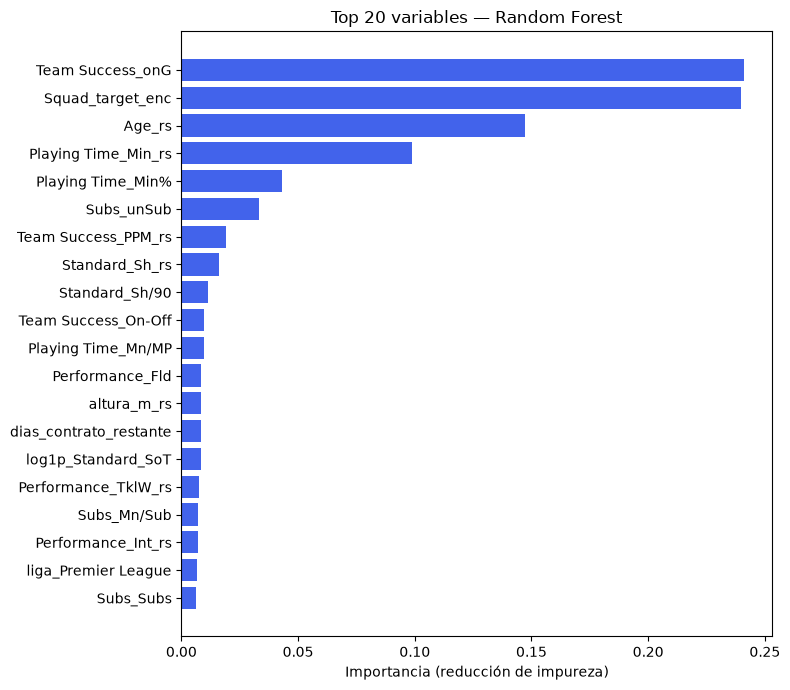

,feature,importancia
0,Team Success_onG,0.241113
1,Squad_target_enc,0.239751
2,Age_rs,0.147428
3,Playing Time_Min_rs,0.098864
4,Playing Time_Min%,0.043014
5,Subs_unSub,0.033369
6,Team Success_PPM_rs,0.019128
7,Standard_Sh_rs,0.016157
8,Standard_Sh/90,0.011552
9,Team Success_On-Off,0.009847


In [24]:
importancias = pd.DataFrame({
    "feature": feature_cols,
    "importancia": rf_tuned.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

top20_rf = importancias.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20_rf["feature"], top20_rf["importancia"], color="#4263eb")
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title("Top 20 variables — Random Forest")
plt.tight_layout()
plt.show()

importancias.head(15)

### 7.2 ¿El Random Forest arregla el piso de mercado y la prima de superestrella?

Repetimos el mismo diagnóstico de residuos de la sección 5, y además puntualmente revisamos qué predice el nuevo modelo para `Rodri` y `Daniel Rodriguez` — los dos casos más extremos que encontramos con la regresión lineal.

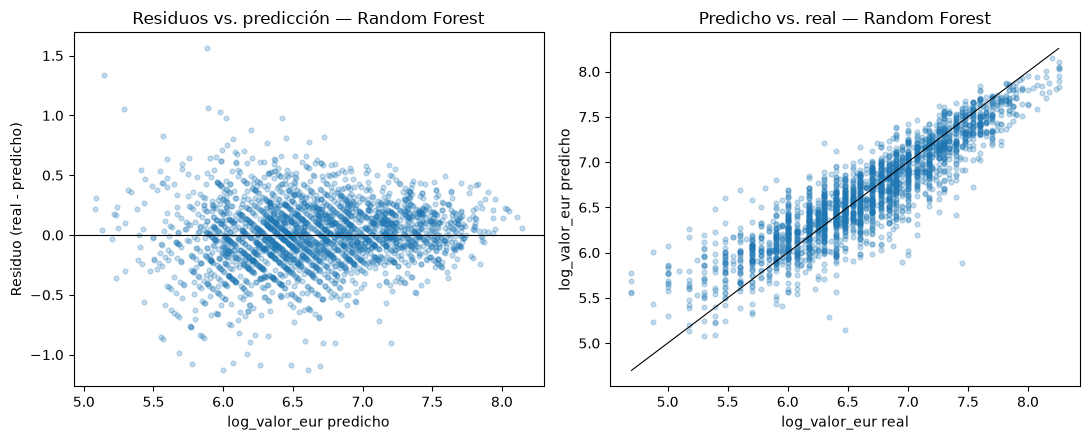

Asimetría (skew) residuos RF: -0.1259  (OLS era -0.40)

Casos puntuales (comparar con la sección 5):


,Player,valor_eur_real,valor_eur_pred


In [25]:
residuos_test_rf = y_test.values - pred_test_rf_tuned

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(pred_test_rf_tuned, residuos_test_rf, alpha=0.25, s=12)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("log_valor_eur predicho")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title("Residuos vs. predicción — Random Forest")

axes[1].scatter(y_test, pred_test_rf_tuned, alpha=0.25, s=12)
lims = [min(y_test.min(), pred_test_rf_tuned.min()), max(y_test.max(), pred_test_rf_tuned.max())]
axes[1].plot(lims, lims, color="black", linewidth=0.8)
axes[1].set_xlabel("log_valor_eur real")
axes[1].set_ylabel("log_valor_eur predicho")
axes[1].set_title("Predicho vs. real — Random Forest")

plt.tight_layout()
plt.show()

print(f"Asimetría (skew) residuos RF: {pd.Series(residuos_test_rf).skew():.4f}  (OLS era -0.40)\n")

resultados_test_rf = pd.DataFrame({
    "Player": df_test["Player"].values,
    "valor_eur_real": df_test["valor_eur"].values,
    "valor_eur_pred": 10 ** pred_test_rf_tuned,
})
print("Casos puntuales (comparar con la sección 5):")
display(resultados_test_rf[resultados_test_rf["Player"].isin(["Rodri", "Daniel Rodriguez"])])

## 8. XGBoost

A diferencia de Random Forest (árboles independientes promediados), XGBoost construye los árboles **secuencialmente**: cada árbol nuevo corrige los errores que dejaron los anteriores (*gradient boosting*). Suele generalizar mejor que Random Forest con menos árboles, pero es más sensible a los hiperparámetros — sobre todo `learning_rate` (qué tan agresivo es cada paso de corrección) y la profundidad/regularización de cada árbol, que si no se controlan llevan a sobreajuste rápido.

Igual que con Random Forest, se buscan los hiperparámetros por validación cruzada (5-fold) sobre el train, sin tocar el test.

In [26]:
from xgboost import XGBRegressor

param_dist_xgb = {
    "n_estimators": [200, 400, 600, 900],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [1, 5, 10],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1, objective="reg:squarederror"),
    param_distributions=param_dist_xgb,
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", xgb_search.best_params_)
print(f"R2 CV (train): {xgb_search.best_score_:.3f}\n")

xgb_best = xgb_search.best_estimator_
pred_train_xgb = xgb_best.predict(X_train)
pred_test_xgb = xgb_best.predict(X_test)

evaluar(y_train, pred_train_xgb, "Train - XGBoost")
evaluar(y_test, pred_test_xgb, "Test - XGBoost")

/home/diego/diplomado/.venv312/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 5, 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
R2 CV (train): 0.823

--- Train - XGBoost ---
R2 (log10):   0.911
RMSE (log10): 0.187
MAE (log10):  0.141
MAE (EUR):    2,707,623
MAPE (EUR):   35.3%

--- Test - XGBoost ---
R2 (log10):   0.831
RMSE (log10): 0.258
MAE (log10):  0.192
MAE (EUR):    3,810,318
MAPE (EUR):   53.2%



### 8.1 Importancia de variables (XGBoost)

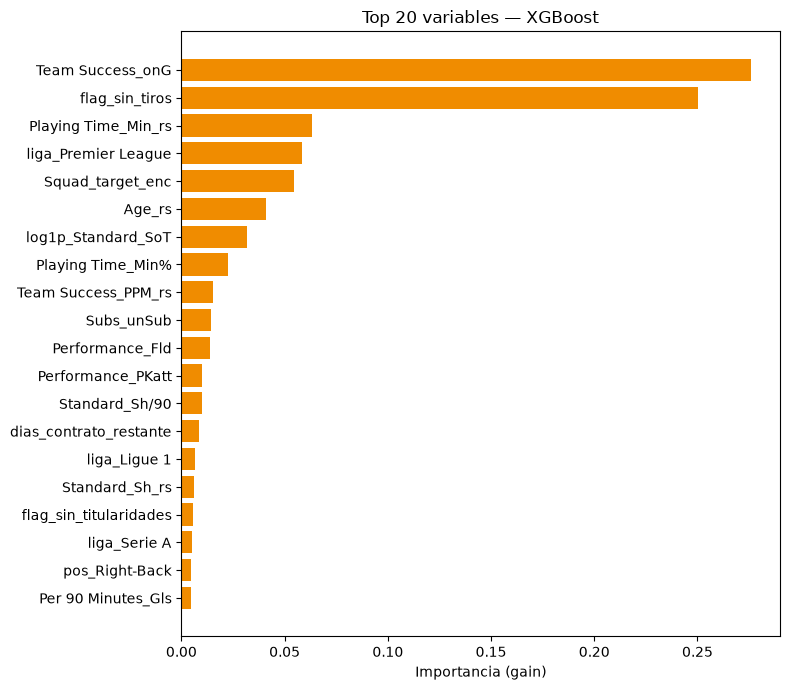

,feature,importancia
0,Team Success_onG,0.276163
1,flag_sin_tiros,0.250241
2,Playing Time_Min_rs,0.063090
3,liga_Premier League,0.058251
4,Squad_target_enc,0.054431
5,Age_rs,0.040807
6,log1p_Standard_SoT,0.031737
7,Playing Time_Min%,0.022750
8,Team Success_PPM_rs,0.015387
9,Subs_unSub,0.014309


In [27]:
importancias_xgb = pd.DataFrame({
    "feature": feature_cols,
    "importancia": xgb_best.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

top20_xgb = importancias_xgb.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20_xgb["feature"], top20_xgb["importancia"], color="#f08c00")
ax.set_xlabel("Importancia (gain)")
ax.set_title("Top 20 variables — XGBoost")
plt.tight_layout()
plt.show()

importancias_xgb.head(15)

## 9. Comparación final de todos los modelos (test)

In [28]:
resumen_final = pd.DataFrame({
    "OLS": metricas(y_test, pred_test),
    "Ridge": metricas(y_test, pred_test_ridge),
    "Lasso": metricas(y_test, pred_test_lasso),
    "Random Forest": metricas(y_test, pred_test_rf_tuned),
    "XGBoost": metricas(y_test, pred_test_xgb),
}).T
resumen_final

,R2 (log10),RMSE (log10),MAE (EUR),MAPE (EUR) %
OLS,0.730721,0.325863,4.825014e+06,78.027386
Ridge,0.731026,0.325678,4.831470e+06,77.877066
Lasso,0.731312,0.325505,4.837111e+06,77.729490
Random Forest,0.811722,0.272479,4.198608e+06,57.272587
XGBoost,0.830926,0.258209,3.810318e+06,53.185725


## 10. Del modelo elegido a producción

XGBoost es el modelo ganador (ver comparación final arriba). El diseño (hiperparámetros, target encoding, lista de features) se congela tal cual en `scripts/build_model_artifacts.py`, que reentrena sobre el 100% de los datos (no solo train — el split aquí era para *medir* generalización, no para decidir qué ve el modelo servido), agrega un SHAP TreeExplainer, percentiles por posición/temporada, y un KMeans de arquetipo, y serializa todo a `models/` + `data/processed/dataset.parquet` para que los consuma el backend de ScoutIA (`app/`). No se reentrena nada acá — ver `AGENTS.md` para el detalle de esa fase.